# Exploratory Data Analysis
### Wind Turbine Physical Evolution: Bigger, Taller, More Powerful?

This is the main analysis notebook. I'm using the cleaned dataset from the previous step.

My problem statement: *Have U.S. wind turbines grown consistently bigger, taller, and more powerful over the last four decades — and which manufacturers drove that growth?*

I'll go through this in 5 parts:
1. Decade-level physical trend analysis
2. Correlation structure between physical dimensions  
3. Manufacturer-level evolution
4. Geographic fleet-age analysis (the California anomaly)
5. Specific power trend (did rotors grow faster than capacity?)


## 0. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# seaborn makes some of the charts look nicer with less code
import seaborn as sns
sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# loading the clean dataset from notebook 02
df = pd.read_csv("../data/cleaned/wind_turbines_clean.csv")

# also loading supporting datasets for later sections
df_wind  = pd.read_csv("../data/original/windiest-states-in-the-us.-2025.csv", encoding="latin1")
df_rates = pd.read_csv("../data/original/average_electricity_rates.csv", encoding="latin1")

print(f"clean dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"decades in dataset: {sorted(
    df['decade'].unique())}")


clean dataset loaded: 65322 rows, 31 columns
decades in dataset: [np.int64(1980), np.int64(1990), np.int64(2000), np.int64(2010), np.int64(2020)]


---
## Part 1: Decade-Level Physical Trend Analysis

**H1:** Average turbine capacity, hub height, and rotor diameter each increased monotonically across every decade from 1980 to 2020.


In [3]:
# group by decade and get mean + median for each physical dimension
# I'm using both mean and median because older/smaller turbines could pull the mean down

decade_stats = df.groupby('decade').agg(
    count        = ('t_cap', 'count'),
    avg_cap      = ('t_cap', 'mean'),
    median_cap   = ('t_cap', 'median'),
    avg_hh       = ('t_hh', 'mean'),
    avg_rd       = ('t_rd', 'mean'),
).round(1)

print("Decade-level summary stats:")
print(decade_stats)


Decade-level summary stats:
        count  avg_cap  median_cap  avg_hh  avg_rd
decade                                            
1980     1307     84.0        65.0    23.5    16.1
1990      880    700.4       750.0    56.7    47.0
2000    20762   1563.5      1500.0    75.1    78.5
2010    33936   2100.9      2000.0    83.9   102.2
2020     8437   2819.5      2800.0    91.4   125.3


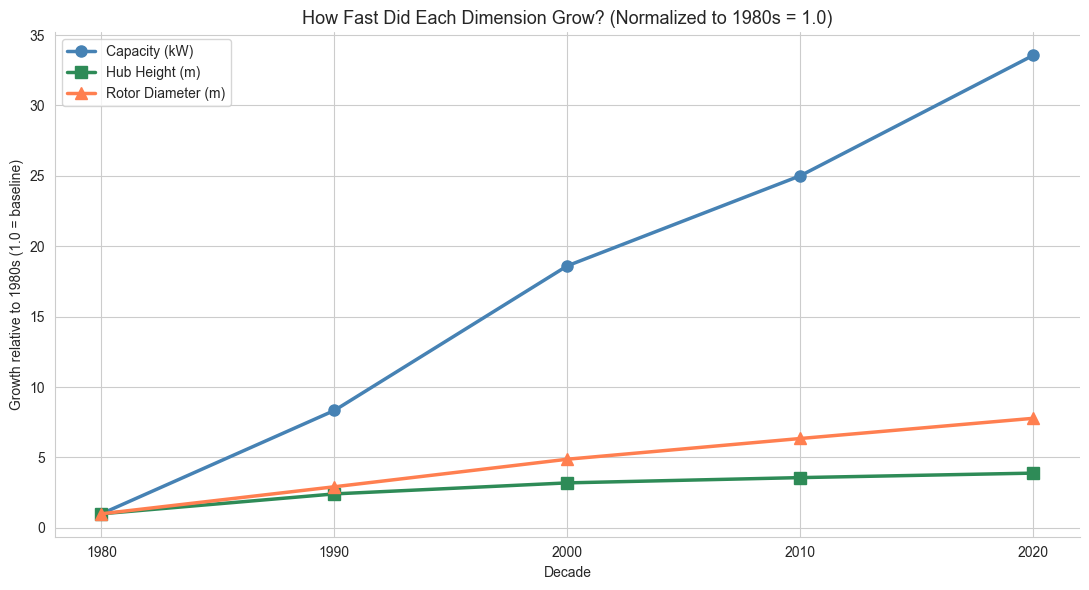

In [4]:
# plotting all 3 physical dimensions on the same chart (normalized)
# I'm normalizing because they're in different units (kW vs meters)
# this way I can see if they all grew at the same rate

fig, ax = plt.subplots(figsize=(11, 6))

decades = decade_stats.index

# normalize each to start at 1 in the 1980s (so we see % growth)
cap_norm = decade_stats['avg_cap'] / decade_stats['avg_cap'].iloc[0]
hh_norm  = decade_stats['avg_hh']  / decade_stats['avg_hh'].iloc[0]
rd_norm  = decade_stats['avg_rd']  / decade_stats['avg_rd'].iloc[0]

ax.plot(decades, cap_norm, 'o-', color='steelblue',   lw=2.5, ms=8, label='Capacity (kW)')
ax.plot(decades, hh_norm,  's-', color='seagreen',    lw=2.5, ms=8, label='Hub Height (m)')
ax.plot(decades, rd_norm,  '^-', color='coral',       lw=2.5, ms=8, label='Rotor Diameter (m)')

ax.set_xlabel("Decade")
ax.set_ylabel("Growth relative to 1980s (1.0 = baseline)")
ax.set_title("How Fast Did Each Dimension Grow? (Normalized to 1980s = 1.0)", fontsize=13)
ax.legend()
ax.set_xticks(decades)
plt.tight_layout()
plt.show()


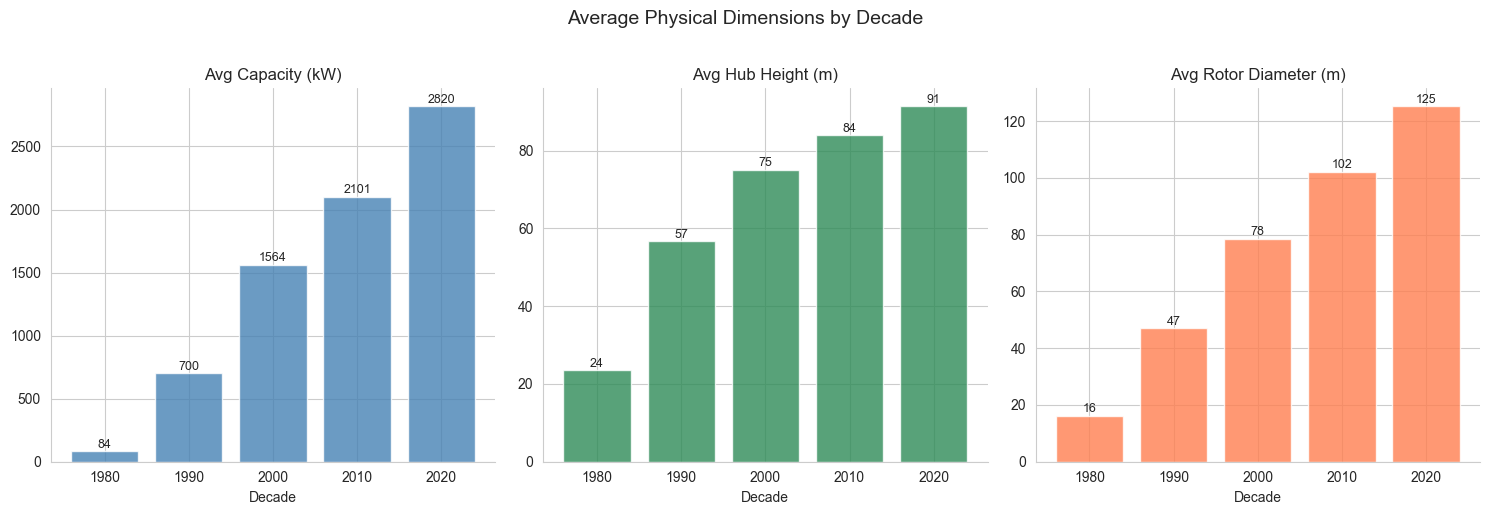

In [5]:
# same data but as a grouped bar chart — easier to compare exact values per decade

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['steelblue', 'seagreen', 'coral']
cols   = ['avg_cap', 'avg_hh', 'avg_rd']
labels = ['Avg Capacity (kW)', 'Avg Hub Height (m)', 'Avg Rotor Diameter (m)']

for i, (col, label, color) in enumerate(zip(cols, labels, colors)):
    axes[i].bar(decade_stats.index.astype(str), decade_stats[col], color=color, alpha=0.8, edgecolor='white')
    axes[i].set_title(label, fontsize=12)
    axes[i].set_xlabel("Decade")
    # adding value labels on top of each bar
    for x, v in zip(range(len(decade_stats)), decade_stats[col]):
        axes[i].text(x, v + decade_stats[col].max()*0.01, f'{v:.0f}', ha='center', fontsize=9)

plt.suptitle("Average Physical Dimensions by Decade", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


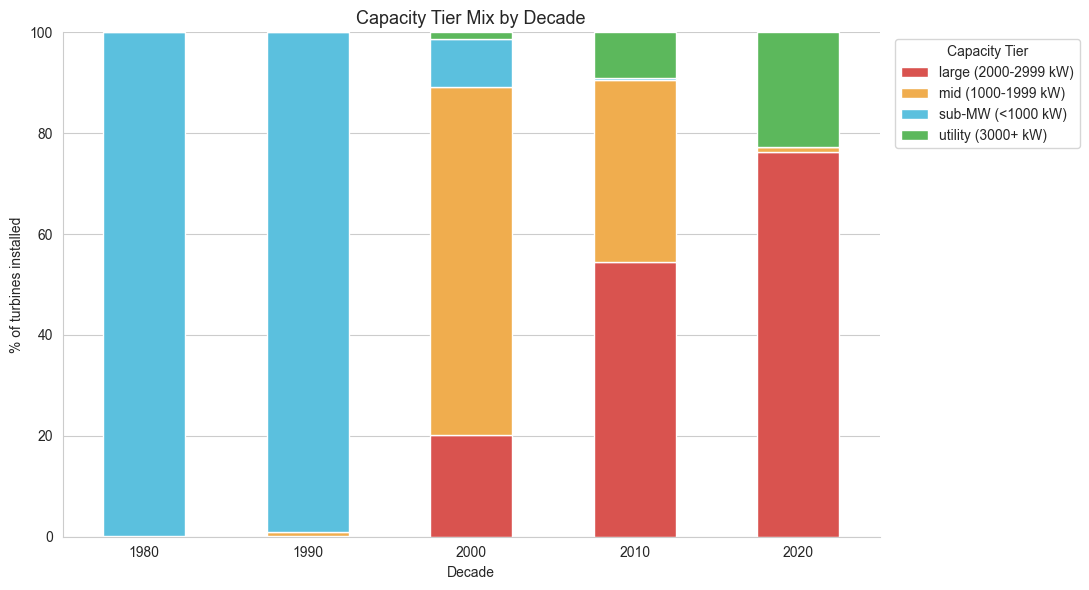

In [6]:
# also showing the capacity tier mix changing over time
# this shows not just averages but how the DISTRIBUTION shifted

tier_decade = df.groupby(['decade', 'capacity_tier'], observed=True).size().unstack(fill_value=0)

# converting to percentages
tier_pct = tier_decade.div(tier_decade.sum(axis=1), axis=0) * 100

tier_pct.plot(kind='bar', stacked=True, figsize=(11, 6),
              color=['#d9534f', '#f0ad4e', '#5bc0de', '#5cb85c'],
              edgecolor='white')

plt.title("Capacity Tier Mix by Decade", fontsize=13)
plt.xlabel("Decade")
plt.ylabel("% of turbines installed")
plt.legend(title="Capacity Tier", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [7]:
# key takeaway numbers for H1
cap_growth = decade_stats['avg_cap'].iloc[-1] / decade_stats['avg_cap'].iloc[0]
hh_growth  = decade_stats['avg_hh'].iloc[-1]  / decade_stats['avg_hh'].iloc[0]
rd_growth  = decade_stats['avg_rd'].iloc[-1]  / decade_stats['avg_rd'].iloc[0]

print("=== Summary: How much did each dimension grow? ===")
print(f"Capacity:       {cap_growth:.1f}x  ({decade_stats['avg_cap'].iloc[0]:.0f} kW → {decade_stats['avg_cap'].iloc[-1]:.0f} kW)")
print(f"Hub Height:     {hh_growth:.1f}x  ({decade_stats['avg_hh'].iloc[0]:.1f}m → {decade_stats['avg_hh'].iloc[-1]:.1f}m)")
print(f"Rotor Diameter: {rd_growth:.1f}x  ({decade_stats['avg_rd'].iloc[0]:.1f}m → {decade_stats['avg_rd'].iloc[-1]:.1f}m)")
print()
print("H1 verdict: all three dimensions increased every decade — hypothesis supported ✓")


=== Summary: How much did each dimension grow? ===
Capacity:       33.6x  (84 kW → 2820 kW)
Hub Height:     3.9x  (23.5m → 91.4m)
Rotor Diameter: 7.8x  (16.1m → 125.3m)

H1 verdict: all three dimensions increased every decade — hypothesis supported ✓


---
## Part 2: Correlation Structure

**H2:** Rotor swept area is a stronger predictor of capacity than hub height alone (r > 0.85).


In [8]:
# correlation matrix for all the physical dimensions
corr_cols = ['t_cap', 't_hh', 't_rd', 't_rsa', 'p_year']
corr_matrix = df[corr_cols].corr().round(3)

print("Correlation matrix:")
print(corr_matrix)


Correlation matrix:
        t_cap   t_hh   t_rd  t_rsa  p_year
t_cap   1.000  0.686  0.879  0.880   0.743
t_hh    0.686  1.000  0.778  0.708   0.751
t_rd    0.879  0.778  1.000  0.977   0.891
t_rsa   0.880  0.708  0.977  1.000   0.850
p_year  0.743  0.751  0.891  0.850   1.000


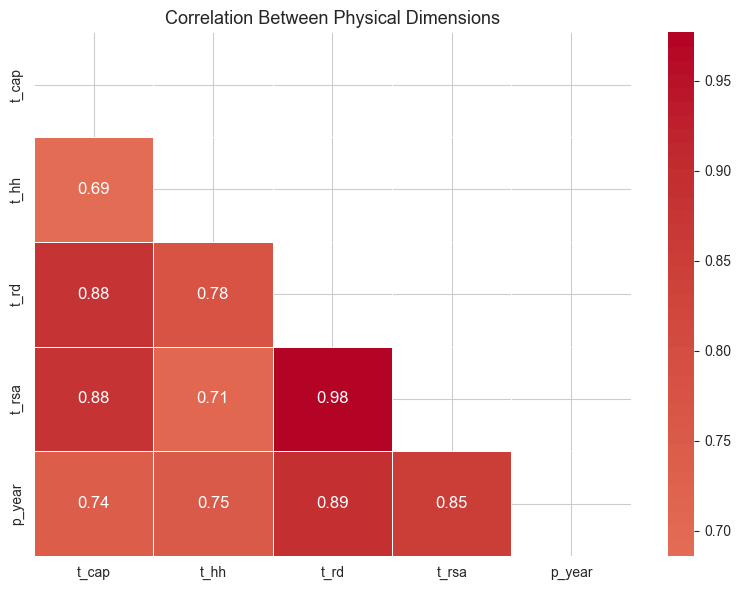

In [9]:
# heatmap is easier to read than raw numbers

fig, ax = plt.subplots(figsize=(8, 6))

# masking the upper triangle so it's not duplicated
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, ax=ax,
            annot_kws={'size': 12}, linewidths=0.5)

ax.set_title("Correlation Between Physical Dimensions", fontsize=13)
plt.tight_layout()
plt.show()


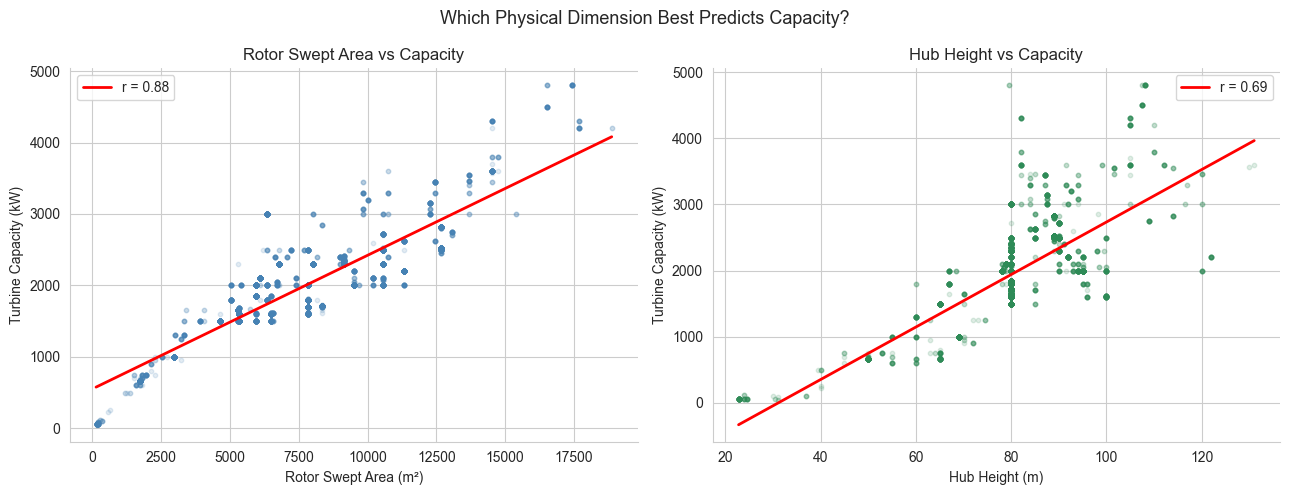

In [10]:
# scatter plot: rotor swept area vs capacity
# adding a trend line too

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# rsa vs cap
sample = df.sample(5000, random_state=42)  # sampling so the plot doesn't get too slow
axes[0].scatter(sample['t_rsa'], sample['t_cap'], alpha=0.15, color='steelblue', s=10)
m, b = np.polyfit(df['t_rsa'].dropna(), df.loc[df['t_rsa'].notna(), 't_cap'], 1)
x_line = np.linspace(df['t_rsa'].min(), df['t_rsa'].max(), 100)
axes[0].plot(x_line, m*x_line + b, color='red', lw=2, label=f'r = {corr_matrix.loc["t_rsa","t_cap"]:.2f}')
axes[0].set_xlabel("Rotor Swept Area (m²)")
axes[0].set_ylabel("Turbine Capacity (kW)")
axes[0].set_title("Rotor Swept Area vs Capacity")
axes[0].legend()

# hh vs cap
axes[1].scatter(sample['t_hh'], sample['t_cap'], alpha=0.15, color='seagreen', s=10)
m2, b2 = np.polyfit(df['t_hh'].dropna(), df.loc[df['t_hh'].notna(), 't_cap'], 1)
x_line2 = np.linspace(df['t_hh'].min(), df['t_hh'].max(), 100)
axes[1].plot(x_line2, m2*x_line2 + b2, color='red', lw=2, label=f'r = {corr_matrix.loc["t_hh","t_cap"]:.2f}')
axes[1].set_xlabel("Hub Height (m)")
axes[1].set_ylabel("Turbine Capacity (kW)")
axes[1].set_title("Hub Height vs Capacity")
axes[1].legend()

plt.suptitle("Which Physical Dimension Best Predicts Capacity?", fontsize=13)
plt.tight_layout()
plt.show()


In [11]:
rsa_r = corr_matrix.loc['t_rsa', 't_cap']
hh_r  = corr_matrix.loc['t_hh',  't_cap']

print("=== H2 Check ===")
print(f"r(rotor swept area, capacity) = {rsa_r:.3f}")
print(f"r(hub height, capacity)       = {hh_r:.3f}")
print()
if rsa_r > 0.85:
    print(f"H2 SUPPORTED — rotor swept area has r={rsa_r:.2f} > 0.85 ✓")
else:
    print(f"H2 NOT SUPPORTED — r={rsa_r:.2f} is below 0.85")


=== H2 Check ===
r(rotor swept area, capacity) = 0.880
r(hub height, capacity)       = 0.686

H2 SUPPORTED — rotor swept area has r=0.88 > 0.85 ✓


---
## Part 3: Manufacturer-Level Evolution

**H3:** GE Wind, Vestas, and Siemens Gamesa drove above-average capacity growth, while smaller or exited manufacturers plateaued earlier.


In [12]:
# which manufacturers have enough data to analyze across decades?
# I'll only include ones with 200+ turbines so the averages are meaningful

manu_counts = df['t_manu'].value_counts()
major_manus = manu_counts[manu_counts >= 200].index.tolist()

print(f"manufacturers with 200+ turbines: {len(major_manus)}")
print(major_manus)


manufacturers with 200+ turbines: 16
['GE Wind', 'Vestas', 'Siemens', 'Gamesa', 'Mitsubishi', 'Siemens Gamesa Renewable Energy', 'Nordex', 'Suzlon', 'Acciona', 'REpower', 'NEG Micon', 'Enron', 'Bonus', 'Clipper', 'Nordtank', 'Micon']


In [13]:
# average capacity by manufacturer and decade
manu_decade = df[df['t_manu'].isin(major_manus)].groupby(
    ['t_manu', 'decade']
)['t_cap'].mean().unstack()

print("Avg capacity (kW) by manufacturer and decade:")
print(manu_decade.round(0))


Avg capacity (kW) by manufacturer and decade:
decade                            1980   1990    2000    2010    2020
t_manu                                                               
Acciona                            NaN    NaN  1500.0  2175.0     NaN
Bonus                             80.0    NaN  1291.0     NaN     NaN
Clipper                            NaN    NaN  2500.0  2500.0     NaN
Enron                              NaN  750.0  1500.0     NaN     NaN
GE Wind                            NaN    NaN  1546.0  1896.0  2696.0
Gamesa                             NaN    NaN  1617.0  2024.0  2100.0
Micon                            119.0    NaN   108.0     NaN     NaN
Mitsubishi                         NaN  600.0  1059.0  2247.0     NaN
NEG Micon                          NaN  707.0  1164.0   412.0     NaN
Nordex                             NaN  600.0  2340.0  2929.0  3828.0
Nordtank                          65.0    NaN    65.0   450.0     NaN
REpower                            NaN    Na

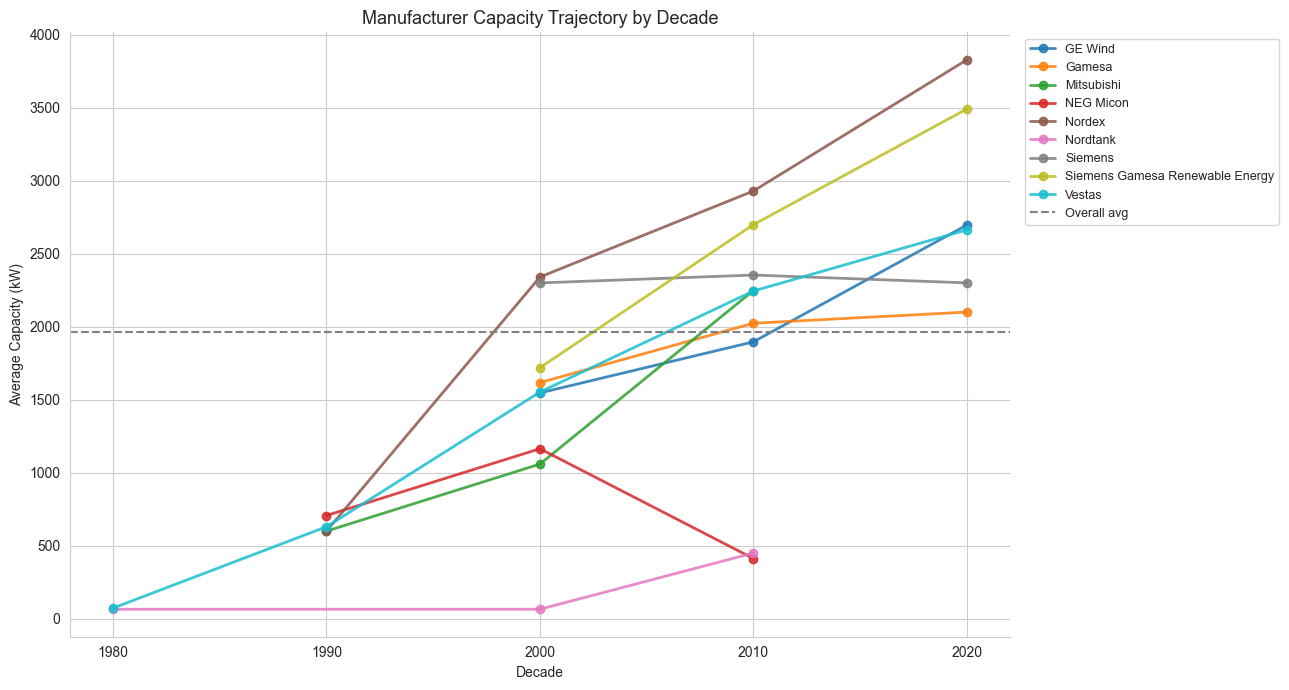

In [14]:
# line chart — one line per manufacturer
# only showing manufacturers that appear in at least 3 decades

manu_decade_filtered = manu_decade.dropna(thresh=3)

fig, ax = plt.subplots(figsize=(13, 7))

colors = plt.cm.tab10(np.linspace(0, 1, len(manu_decade_filtered)))

for i, (manu, row) in enumerate(manu_decade_filtered.iterrows()):
    row_clean = row.dropna()
    if len(row_clean) >= 2:
        ax.plot(row_clean.index, row_clean.values, 'o-', lw=2, ms=6,
                color=colors[i], label=manu, alpha=0.85)

ax.axhline(y=df['t_cap'].mean(), color='gray', linestyle='--', lw=1.5, label='Overall avg')
ax.set_xlabel("Decade")
ax.set_ylabel("Average Capacity (kW)")
ax.set_title("Manufacturer Capacity Trajectory by Decade", fontsize=13)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.set_xticks(manu_decade.columns)
plt.tight_layout()
plt.show()


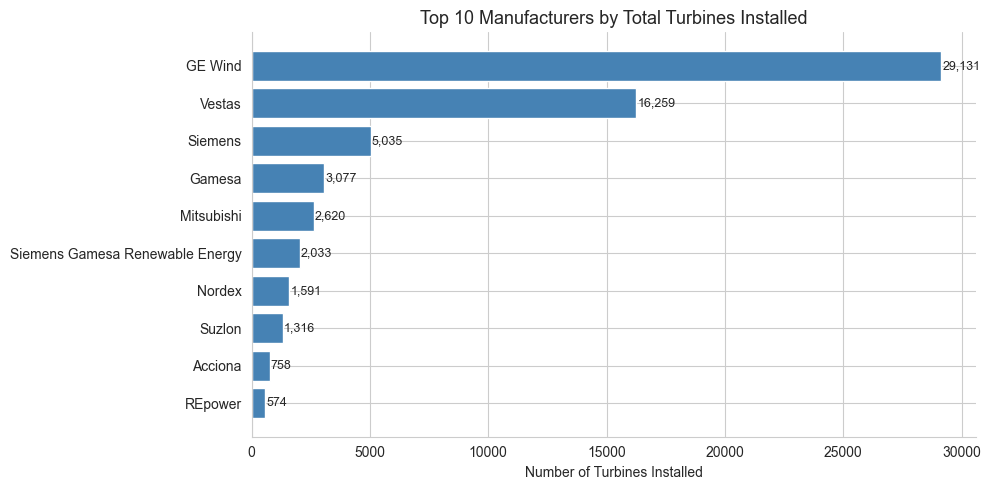

In [15]:
# bar chart showing total turbines installed per manufacturer — market share
top10_manu = df['t_manu'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top10_manu.index[::-1], top10_manu.values[::-1], color='steelblue', edgecolor='white')
ax.set_xlabel("Number of Turbines Installed")
ax.set_title("Top 10 Manufacturers by Total Turbines Installed", fontsize=13)

# adding count labels
for i, (v, name) in enumerate(zip(top10_manu.values[::-1], top10_manu.index[::-1])):
    ax.text(v + 50, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


In [16]:
# checking the GE Wind numbers specifically since they dominate
ge = df[df['t_manu'] == 'GE Wind'].groupby('decade')['t_cap'].agg(['mean','count'])
print("GE Wind capacity by decade:")
print(ge.round(1))


GE Wind capacity by decade:
          mean  count
decade               
2000    1546.5   9542
2010    1896.4  15488
2020    2696.1   4101


---
## Part 4: Geographic Fleet-Age Analysis

**H4:** States that adopted wind energy earlier (pre-2000) have a measurably lower average turbine capacity than states whose fleets are predominantly post-2010 installations.


In [20]:
# state-level summary: avg capacity, avg install year, turbine count
state_summary = df.groupby('t_state').agg(
    turbine_count = ('case_id', 'count'),
    avg_cap_kw    = ('t_cap', 'mean'),
    avg_year      = ('p_year', 'mean'),
).round(1).reset_index()

print("state summary (top 15 by turbine count):")
print(state_summary.sort_values('turbine_count', ascending=False).head(15))


state summary (top 15 by turbine count):
   t_state  turbine_count  avg_cap_kw  avg_year
37      TX          16687      2072.7    2013.0
9       IA           5968      1973.9    2012.3
30      OK           4556      2143.9    2013.9
3       CA           4286      1360.4    2002.0
13      KS           3622      2020.7    2013.7
11      IL           3248      1962.4    2012.7
4       CO           2733      1783.4    2012.4
18      MN           2674      1696.7    2010.3
22      ND           2092      2040.2    2013.1
31      OR           2058      1829.3    2008.9
41      WA           1822      1863.8    2008.1
17      MI           1548      2083.0    2015.1
12      IN           1536      2050.3    2012.8
44      WY           1423      2204.1    2011.9
26      NM           1394      2036.1    2013.9


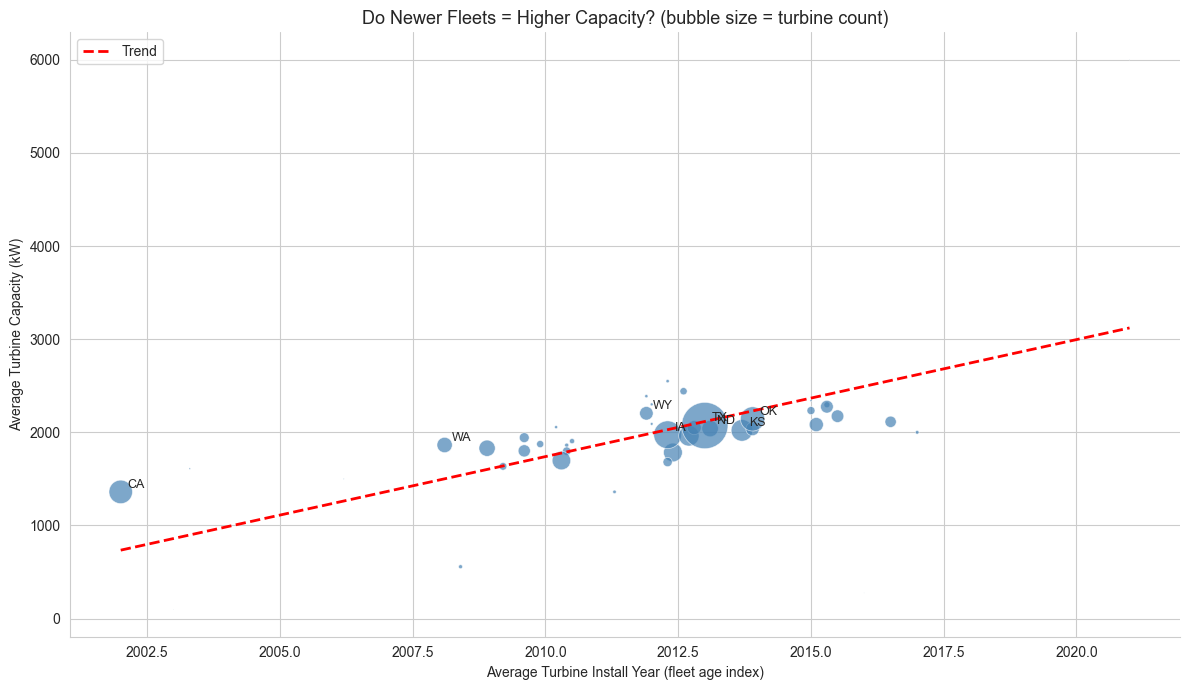

In [18]:
# scatter plot: avg install year vs avg capacity by state
# each dot is a state, sized by number of turbines

fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(
    state_summary['avg_year'],
    state_summary['avg_cap_kw'],
    s=state_summary['turbine_count'] / 15,  # size = turbine count
    alpha=0.7,
    color='steelblue',
    edgecolors='white',
    linewidth=0.5
)

# labeling a few interesting states
highlight = ['TX', 'IA', 'CA', 'WY', 'OK', 'KS', 'ND', 'WA']
for _, row in state_summary[state_summary['t_state'].isin(highlight)].iterrows():
    ax.annotate(row['t_state'],
                xy=(row['avg_year'], row['avg_cap_kw']),
                xytext=(5, 3), textcoords='offset points', fontsize=9)

# trend line
m, b = np.polyfit(state_summary['avg_year'], state_summary['avg_cap_kw'], 1)
x_line = np.linspace(state_summary['avg_year'].min(), state_summary['avg_year'].max(), 100)
ax.plot(x_line, m*x_line + b, color='red', lw=2, linestyle='--', label='Trend')

ax.set_xlabel("Average Turbine Install Year (fleet age index)")
ax.set_ylabel("Average Turbine Capacity (kW)")
ax.set_title("Do Newer Fleets = Higher Capacity? (bubble size = turbine count)", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()


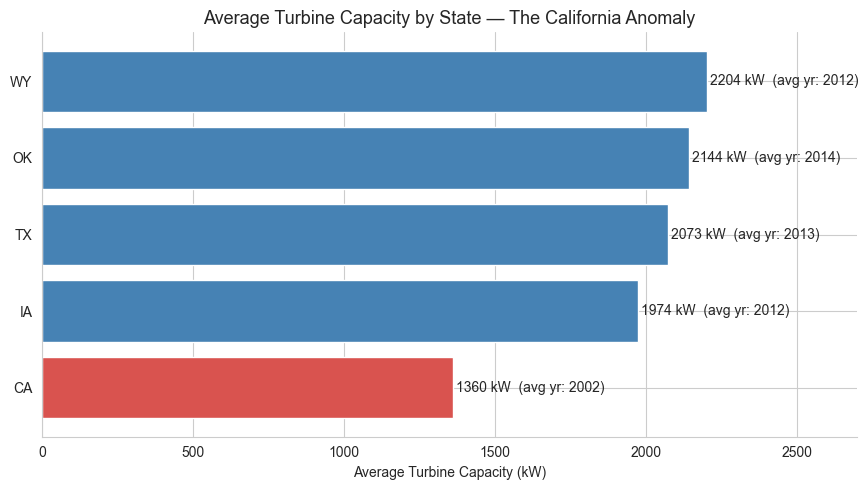

California's avg install year vs. Texas:
   t_state  avg_year  avg_cap_kw
3       CA    2002.0      1360.4
9       IA    2012.3      1973.9
37      TX    2013.0      2072.7


In [21]:
# the california anomaly — comparing CA, TX, IA directly

focus_states = ['CA', 'TX', 'IA', 'WY', 'OK']
comparison = state_summary[state_summary['t_state'].isin(focus_states)].sort_values('avg_cap_kw')

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(comparison['t_state'], comparison['avg_cap_kw'],
               color=['#d9534f' if s == 'CA' else 'steelblue' for s in comparison['t_state']],
               edgecolor='white')

# adding value labels
for bar, val, yr in zip(bars, comparison['avg_cap_kw'], comparison['avg_year']):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{val:.0f} kW  (avg yr: {yr:.0f})', va='center', fontsize=10)

ax.set_xlabel("Average Turbine Capacity (kW)")
ax.set_title("Average Turbine Capacity by State — The California Anomaly", fontsize=13)
ax.set_xlim(0, 2700)
plt.tight_layout()
plt.show()

print("California's avg install year vs. Texas:")
print(state_summary[state_summary['t_state'].isin(['CA','TX','IA'])][['t_state','avg_year','avg_cap_kw']])


---
## Part 5: Specific Power Trend

**H5:** Specific power (W/m²) has decreased over time, reflecting a shift toward larger rotors optimized for lower wind speed sites.


In [22]:
# avg specific power by decade
sp_decade = df.groupby('decade')['specific_power'].agg(['mean','median','count']).round(1)

print("Specific power (W/m2) by decade:")
print(sp_decade)


Specific power (W/m2) by decade:
         mean  median  count
decade                      
1980    347.2   353.5    931
1990    399.0   382.0    871
2000    322.0   322.1  20741
2010    259.5   251.1  33903
2020    225.3   222.6   8421


In [ ]:
# line chart of specific power over time

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(sp_decade.index, sp_decade['mean'],   'o-', color='mediumpurple', lw=2.5, ms=8, label='Mean')
ax.plot(sp_decade.index, sp_decade['median'], 's--', color='orchid',     lw=2,   ms=7, label='Median')

ax.set_xlabel("Decade")
ax.set_ylabel("Specific Power (W/m²)")
ax.set_title("Specific Power Trend Over Time")
ax.legend()
ax.set_xticks(sp_decade.index)
plt.tight_layout()
plt.show()


SyntaxError: unterminated string literal (detected at line 10) (1575578330.py, line 10)

In [24]:
sp_1980 = sp_decade['mean'].iloc[0]
sp_2020 = sp_decade['mean'].iloc[-1]

print("=== H5 Check ===")
print(f"Specific power in 1980s: {sp_1980:.1f} W/m²")
print(f"Specific power in 2020s: {sp_2020:.1f} W/m²")
change = (sp_2020 - sp_1980) / sp_1980 * 100
if change < 0:
    print(f"Change: {change:.1f}%  — DECREASED over time")
    print("H5 SUPPORTED — rotors grew faster than capacity (optimizing for lower wind sites) ✓")
else:
    print(f"Change: {change:.1f}%  — INCREASED over time")
    print("H5 NOT SUPPORTED — capacity grew faster than rotor size")


=== H5 Check ===
Specific power in 1980s: 347.2 W/m²
Specific power in 2020s: 225.3 W/m²
Change: -35.1%  — DECREASED over time
H5 SUPPORTED — rotors grew faster than capacity (optimizing for lower wind sites) ✓
